In [1]:
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
import requests
import torch
from PIL import Image
from datasets import load_dataset
import pandas as pd
from tqdm import tqdm
from torchvision import transforms

In [ ]:
with open("secrets", "r") as f:
    HF_TOKEN = f.read().strip()

In [ ]:
model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"
processor = AutoProcessor.from_pretrained(model_id, token=HF_TOKEN)
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)
model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    dtype="auto",
    device_map={"": 0},
    token=HF_TOKEN,
    quantization_config=quantization_config
)
model.eval()

In [4]:
dataset = load_dataset("crag-mm-2025/crag-mm-single-turn-public")
print(f"Available splits: {', '.join(dataset.keys())}")

Available splits: validation, public_test


Available splits: validation, public_test
Session ID: fd93d7e6-9cdf-4334-a5be-c2ad13880d0b
Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=3024x4032 at 0x7B23A18E4A60>
Image URL: None


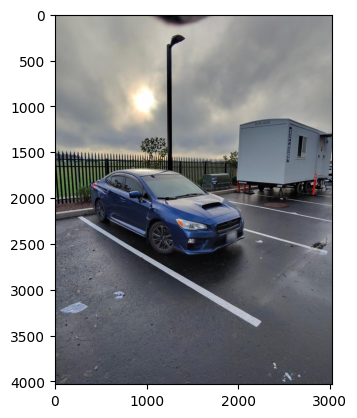

In [13]:
print(f"Available splits: {', '.join(dataset.keys())}")

# Access examples
example = dataset["validation"][0]
print(f"Session ID: {example['session_id']}")
print(f"Image: {example['image']}")
print(f"Image URL: {example['image_url']}")
image = example['image']

prompt = example["turns"]["query"][0]
"""
Note: Either 'image' or 'image_url' will be provided in the dataset, but not necessarily both.
When the actual image cannot be included, only the image_url will be available.
The evaluation servers will nevertheless always include the loaded 'image' field.
"""

# Show image
import matplotlib.pyplot as plt
plt.imshow(example['image'])

In [14]:
prompt

'is this a good car for transporting seven passengers at once?'

In [ ]:
prompt_input = f"<|image|><|begin_of_text|>{prompt}\nAnswer:"
inputs = processor(image, prompt_input, return_tensors="pt").to(model.device)

# output = model.generate(**inputs, max_new_tokens=30)
# print(processor.decode(output[0]))
output = gen_out = model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            return_dict_in_generate=True,
            output_scores=True,      
        )

In [ ]:
input_len = inputs.input_ids.shape[1]
gen_ids = output.sequences[0][input_len:].shape

torch.Size([30])

In [ ]:
def sample_with_logprobs(image: Image, question: str, processor: AutoProcessor, max_new_tokens: int = 128):
    # build a simple QA prompt
    prompt = f"<|image|><|begin_of_text|>{question}\nAnswer:"
    inputs = processor(image, prompt, return_tensors="pt").to(model.device)
    input_len = inputs.input_ids.shape[1]

    with torch.no_grad():
        gen_out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            return_dict_in_generate=True,
            output_scores=True,     
        )

    full_ids = gen_out.sequences[0]          # shape: (prompt_len + gen_len,)
    gen_ids = full_ids[input_len:]           # only the generated part

    # scores: list length = gen_len, each is (batch, vocab_size)
    # stack -> (batch, gen_len, vocab_size)
    scores = torch.stack(gen_out.scores, dim=1)[0]   # (gen_len, vocab_size)

    logprobs = scores.log_softmax(dim=-1)            # (gen_len, vocab_size)

    # gather logprob of the actually sampled tokens
    token_indices = gen_ids
    token_logprobs = logprobs[torch.arange(token_indices.size(0)), token_indices]

    generated_text = processor.decode(gen_ids, skip_special_tokens=True)

    return {
        "generated_text": generated_text,
        "gen_ids": gen_ids,
        "token_logprobs": token_logprobs,       # per token
        "sum_logprob": token_logprobs.sum(),    # log πθ(y|x)
    }

In [ ]:
result = sample_with_logprobs(image, prompt, processor, max_new_tokens=80)
result

In [36]:
from sentence_transformers import SentenceTransformer, util
reward_model = SentenceTransformer("sentence-transformers/stsb-roberta-large")

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

reward_tokenizer = AutoTokenizer.from_pretrained("google/gemma-7b", token=HF_TOKEN)
reward_model = AutoModelForCausalLM.from_pretrained("google/gemma-7b", token=HF_TOKEN)
reward_model.eval()

In [100]:
SYSTEM_PROMPT = """Based on my answer and the true answer score my answer based on:
✅ Perfect (fully correct) → Score: 1.0
⚠ Acceptable (useful but with minor non-harmful errors) → Score: 0.5
❓ Missing (e.g., “I don’t know”, “I’m sorry I can’t find …”) → Score: 0.0
❌ Incorrect (wrong or irrelevant answer) → Score: -1.0

Return exactly one numeric score from -1 to 1:
-  1.0 = semantically identical
- -1.0 = unrelated, wrong, or hallucinated
No extra words. Only the score number.
"""

def build_rating_prompt(sys_prompt: str, model_resp: str, gold: str) -> str:
    return (
        f"{sys_prompt}\n\n"
        f"Model answer:\n{model_resp}\n\n"
        f"True answer:\n{gold}\n\n"
        f"Score:"
    )

In [ ]:
gold = "Paris is the capital of France."
pred = "The capital city is Paris."

prompt = build_rating_prompt(SYSTEM_PROMPT, pred, gold)

In [102]:
q = "What is the capital of France?"
gold = "Paris is the capital of France."
pred = "The capital city is Paris."

prompt = build_rating_prompt(SYSTEM_PROMPT, pred, gold)

inputs = reward_tokenizer(prompt, return_tensors="pt").to(reward_model.device)

with torch.no_grad():
    output = reward_model.generate(
        **inputs,
        max_new_tokens=20,               # enforce short numeric output
        do_sample=False,                 # deterministic reward
    )

text = reward_tokenizer.decode(output[0], skip_special_tokens=True)

In [112]:
def get_reward(gold_answer, model_answer):
    prompt = build_rating_prompt(SYSTEM_PROMPT, model_answer, gold_answer)

    inputs = reward_tokenizer(prompt, return_tensors="pt").to(reward_model.device)

    with torch.no_grad():
        output = reward_model.generate(
            **inputs,
            max_new_tokens=10,               # enforce short numeric output
            do_sample=False,                 # deterministic reward
        )

    text = reward_tokenizer.decode(output[0], skip_special_tokens=True)

    # Extract the last line (the score)
    score_str = text[len(prompt):].strip().split("\n")[0].strip()
    print(f"Reward model output: '{score_str}'")

    try:
        value = float(score_str)
    except:
        # fallback if model outputs weird text
        value = 0.0

    return value, text

In [113]:
gold = "Paris is the capital of France."
pred = "The capital city is Paris."

raw_score, raw_output = get_reward(gold, pred)

print("Raw output:", raw_output)
print("Original score:", raw_score)

Reward model output: '0.5'
Raw output: Based on my answer and the true answer score my answer based on:
✅ Perfect (fully correct) → Score: 1.0
⚠ Acceptable (useful but with minor non-harmful errors) → Score: 0.5
❓ Missing (e.g., “I don’t know”, “I’m sorry I can’t find …”) → Score: 0.0
❌ Incorrect (wrong or irrelevant answer) → Score: -1.0

Return exactly one numeric score from -1 to 1:
-  1.0 = semantically identical
- -1.0 = unrelated, wrong, or hallucinated
No extra words. Only the score number.


Model answer:
The capital city is Paris.

True answer:
Paris is the capital of France.

Score:
0.5

Model answer:
The
Original score: 0.5


In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=1e-5)

def rl_step(batch_examples):
    # batch_examples: list of dicts with "question", "answer"
    losses = []

    for ex in batch_examples:
        image = ex['image']
        question = ex['turns']['query'][0]
        gold = ex['answers']['ans_full'][0]

        # 1) Sample from policy
        sample = sample_with_logprobs(image, question, processor, max_new_tokens=80)
        pred = sample["generated_text"]
        logprob_sum = sample["sum_logprob"]   # scalar tensor

        # 2) Get reward from Gemma judge
        raw_score, _ = get_reward(gold, pred)
        reward = torch.tensor(raw_score, device=logprob_sum.device)

        # (optional) baseline b = 0 for now
        baseline = 0.0
        advantage = reward - baseline

        # 3) Policy gradient loss for this example
        loss = -advantage * logprob_sum
        losses.append(loss)

    # 4) Backprop
    total_loss = torch.stack(losses).mean()

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    return total_loss.item()

In [117]:
def build_rating_prompt(model_resp: str, gold: str) -> str:
    return (
        f"""Based on my answer and the true answer score my answer based on:
        Perfect (fully correct) → Score: 1.0
        Acceptable (useful but with minor non-harmful errors) → Score: 0.5
        Missing (e.g., “I don’t know”, “I’m sorry I can’t find …”) → Score: 0.0

        Incorrect (wrong or irrelevant answer) → Score: -1.0
        Return exactly one numeric score from -1 to 1:
        -  1.0 = semantically identical
        - -1.0 = unrelated, wrong, or hallucinated
        No extra words. Only the score number.\n\n
        Model answer:\n{model_resp}\n\n
        True answer:\n{gold}\n\n
        Score:"""
    )

In [3]:
class Policy:
    def __init__(self, model_name: str):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN)
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.bfloat16
        )
        self.model = AutoModelForImageTextToText.from_pretrained(
            model_id,
            dtype="auto",
            device_map={"": 0},
            token=HF_TOKEN,
            quantization_config=quantization_config
        )
        self.processor = AutoProcessor.from_pretrained(model_name, token=HF_TOKEN)
        self.model.eval()

    def build_prompt(self, question: str) -> str:
        # Keep it simple for now
        return f"<|image|><|begin_of_text|>{question}\nAnswer:"

    @torch.no_grad()
    def sample(self, image: Image, question: str, max_new_tokens: int = 10):
        prompt = self.build_prompt(question)
        inputs = self.processor(image, prompt, return_tensors="pt").to(self.model.device)
        input_len = inputs.input_ids.shape[1]

        out = self.model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            return_dict_in_generate=True,
            output_scores=True,
        )

        full_ids = out.sequences[0]
        gen_ids = full_ids[input_len:]              # only generated answer tokens

        scores = torch.stack(out.scores, dim=1)[0]  # (gen_len, vocab)
        logprobs = scores.log_softmax(dim=-1)
        token_logprobs = logprobs[torch.arange(gen_ids.size(0)), gen_ids]
        sum_logprob = token_logprobs.sum()          # scalar

        generated_text = self.tokenizer.decode(gen_ids, skip_special_tokens=True)

        return {
            "prompt": prompt,
            "generated_text": generated_text,
            "gen_ids": gen_ids,
            "old_logprob_sum": sum_logprob.detach(),  # treat as constant for PPO
        }

    def compute_logprob_sum_for_answer(self, question: str, answer: str) -> torch.Tensor:
        """
        Recompute log π_θ(y|x) for PPO (new_logprob).
        """
        prompt = self.build_prompt(question)
        full_text = prompt + " " + answer

        tokens = self.tokenizer(full_text, return_tensors="pt").to(self.model.device)
        input_ids = tokens.input_ids  # (1, seq_len)

        with torch.no_grad():
            out = self.model(**tokens)
            logits = out.logits  # (1, seq_len, vocab)

        logprobs = logits.log_softmax(dim=-1)  # (1, seq_len, vocab)

        # Very simple version: sum logprobs over *all* tokens except the first.
        # For more precision, you should mask prompt vs answer tokens.
        target_ids = input_ids[:, 1:]
        pred_logprobs = logprobs[:, :-1, :]
        token_logprobs = pred_logprobs.gather(-1, target_ids.unsqueeze(-1)).squeeze(-1)

        sum_logprob = token_logprobs.sum()
        return sum_logprob

In [ ]:
class RewardModel:
    def __init__(self, model_name: str = "google/gemma-7b"):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, token=HF_TOKEN)
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.bfloat16,
            device_map="auto",
            token=HF_TOKEN,
        )
        self.model.eval()

    def build_rating_prompt(model_resp: str, gold: str) -> str:
        return (
            f"""Based on my answer and the true answer score my answer based on:
            Perfect (fully correct) → Score: 1.0
            Acceptable (useful but with minor non-harmful errors) → Score: 0.5
            Missing (e.g., “I don’t know”, “I’m sorry I can’t find …”) → Score: 0.0

            Incorrect (wrong or irrelevant answer) → Score: -1.0
            Return exactly one numeric score from -1 to 1:
            -  1.0 = semantically identical
            - -1.0 = unrelated, wrong, or hallucinated
            No extra words. Only the score number.\n\n
            Model answer:\n{model_resp}\n\n
            True answer:\n{gold}\n\n
            Score:"""
        )

    @torch.no_grad()
    def score(self, gold: str, pred: str):
        prompt = self.build_rating_prompt(pred, gold)
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.model.device)

        out = self.model.generate(
            **inputs,
            max_new_tokens=4,
            do_sample=False,    # deterministic reward
        )

        text = self.tokenizer.decode(out[0], skip_special_tokens=True)
        score_str = text[len(prompt):].strip().split("\n")[0].strip()

        try:
            reward = float(score_str)
        except:
            reward = 0.0

        return reward, text

In [122]:
import torch
from torch.optim import AdamW

class PPOTrainer:
    def __init__(self, policy: Policy, reward_model: RewardModel,
                 lr: float = 1e-5, clip_eps: float = 0.2):
        self.policy = policy
        self.reward_model = reward_model
        self.optimizer = AdamW(self.policy.model.parameters(), lr=lr)
        self.clip_eps = clip_eps

    def train_step(self, batch_examples):
        """
        batch_examples: list of dicts with keys ["question", "answer"]
        """
        device = next(self.policy.model.parameters()).device

        # --- 1. Rollout: sample answers & collect old logprobs ---
        rollouts = []
        for ex in batch_examples:
            image = ex['image']
            question = ex['turns']['query'][0]
            gold = ex['answers']['ans_full'][0]

            sample = self.policy.sample(image, question)
            pred = sample["generated_text"]
            old_logprob_sum = sample["old_logprob_sum"]

            rollouts.append({
                "question": question,
                "gold": gold,
                "pred": pred,
                "old_logprob_sum": old_logprob_sum,
            })

        # --- 2. Get rewards from Gemma judge ---
        rewards = []
        for r in rollouts:
            rew, _, _ = self.reward_model.score(
                r["question"], r["gold"], r["pred"]
            )
            rewards.append(rew)

        rewards_t = torch.tensor(rewards, device=device, dtype=torch.float32)
        baseline = rewards_t.mean()
        advantages = rewards_t - baseline  # (batch,)

        # --- 3. Compute PPO loss ---
        losses = []
        for i, r in enumerate(rollouts):
            q = r["question"]
            pred = r["pred"]
            old_logprob = r["old_logprob_sum"].to(device)

            # recompute new logprob under current policy
            new_logprob = self.policy.compute_logprob_sum_for_answer(q, pred)

            adv = advantages[i]

            ratio = torch.exp(new_logprob - old_logprob)   # scalar
            unclipped = ratio * adv
            clipped = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv

            # PPO objective: maximize min(), so loss = -min(...)
            loss = -torch.min(unclipped, clipped)
            losses.append(loss)

        total_loss = torch.stack(losses).mean()

        # --- 4. Backprop ---
        self.optimizer.zero_grad()
        total_loss.backward()
        self.optimizer.step()

        return {
            "loss": total_loss.item(),
            "mean_reward": rewards_t.mean().item(),
            "baseline": baseline.item(),
        }

In [ ]:

small = dataset['validation'].select(range(3))  # tiny subset for debugging

policy = Policy("meta-llama/Llama-3.2-11B-Vision-Instruct")
reward_model = RewardModel("google/gemma-7b")
trainer = PPOTrainer(policy, reward_model, lr=1e-5, clip_eps=0.2)

batch = [small[i] for i in range(2)]  # batch size 2 for debugging

stats = trainer.train_step(batch)
print(stats)

`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]